# 04. Python API 提交、取回与可视化

使用 `submit_task(backend="dummy")` 验证远端任务接口的本地替代路径：提交、等待、查询缓存、画图。`backend="dummy"` 表示无约束、无噪声；需要虚拟拓扑时使用 `dummy:virtual-line-N` / `dummy:virtual-grid-RxC`，需要真实芯片噪声时使用 `dummy:<platform>:<backend>`。


In [1]:
import math
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from uniqc import Circuit
from uniqc.simulator import OriginIR_Simulator


def probability_dict(values):
    if isinstance(values, dict):
        total = sum(values.values()) or 1
        return {format(int(k), "b") if isinstance(k, int) else str(k): v / total for k, v in values.items()}
    n = int(math.log2(len(values))) if values else 0
    return {format(i, f"0{n}b"): float(p) for i, p in enumerate(values) if abs(float(p)) > 1e-12}


def plot_probs(probs, title):
    labels = list(probs)
    values = [probs[k] for k in labels]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(labels, values, color="#3267a8")
    ax.set_ylim(0, max(1.0, max(values, default=0) * 1.2))
    ax.set_xlabel("bitstring")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()


task_id: 9dc41044252bdac8
status: success
counts: {'00': 64, '11': 64}


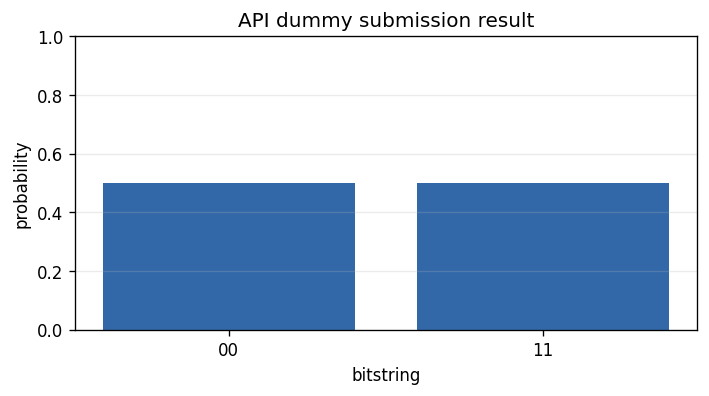

In [2]:
from uniqc import get_task, submit_task, wait_for_result

circuit = Circuit()
circuit.h(0)
circuit.cnot(0, 1)
circuit.measure(0, 1)

task_id = submit_task(circuit, backend="dummy", shots=128, metadata={"example": "best-practices-api"})
counts = wait_for_result(task_id)
task = get_task(task_id)

print("task_id:", task_id)
print("status:", task.status)
print("counts:", counts)

probs = {k: v / sum(counts.values()) for k, v in counts.items()}
plot_probs(probs, "API dummy submission result")
